# Support Vector Machines (SVM) — Credit Card Fraud Detection

## Overview
In this notebook, we apply **Support Vector Machines (SVM)** to classify fraudulent credit card transactions using the [Credit Card Fraud Detection dataset](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) from Kaggle.

We cover:
- SVM intuition and theory
- Linear SVM from scratch using gradient descent
- SVM with scikit-learn (linear and RBF kernel)
- Evaluation using accuracy, precision, recall, and F1-score

## What is SVM?
SVM finds the **optimal hyperplane** that maximizes the margin between classes. For a linear SVM, we solve:

$$\min_{w, b} \frac{1}{2} \|w\|^2 + C \sum_{i=1}^{n} \max(0, 1 - y_i(w \cdot x_i - b))$$

The first term maximizes the margin, while the second term (hinge loss) penalizes misclassifications. $C$ controls the trade-off between margin size and classification error.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

pd.set_option('display.max_columns', 50)
plt.style.use('seaborn-v0_8')
%matplotlib inline

## 1. Load & Preprocess Data

In [2]:
df = pd.read_csv('/Users/apple/Desktop/CMOR438/CMOR438-Spring2026/data/credit_fraud/creditcard.csv')

fraud = df[df['Class'] == 1]
normal = df[df['Class'] == 0].sample(len(fraud), random_state=42)
df_balanced = pd.concat([fraud, normal]).sample(frac=1, random_state=42)

X = df_balanced.drop('Class', axis=1).values
y = df_balanced['Class'].values
y_svm = np.where(y == 0, -1, 1)  # SVM uses -1/+1 labels

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
_, _, y_train_svm, y_test_svm = train_test_split(X, y_svm, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (787, 30)
Test set size: (197, 30)


## 2. Linear SVM from Scratch

In [3]:
class LinearSVMScratch:
    def __init__(self, C=1.0, lr=0.001, epochs=1000):
        self.C = C
        self.lr = lr
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.losses = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for epoch in range(self.epochs):
            loss = 0
            for i, x_i in enumerate(X):
                margin = y[i] * (x_i @ self.weights - self.bias)
                if margin >= 1:
                    dw = self.weights
                    db = 0
                else:
                    dw = self.weights - self.C * y[i] * x_i
                    db = -self.C * y[i]
                    loss += 1 - margin
                self.weights -= self.lr * dw
                self.bias -= self.lr * db
            self.losses.append(0.5 * np.dot(self.weights, self.weights) + self.C * loss)

    def predict(self, X):
        return np.sign(X @ self.weights - self.bias).astype(int)

# Train
svm_scratch = LinearSVMScratch(C=1.0, lr=0.001, epochs=50)
svm_scratch.fit(X_train_scaled, y_train_svm)

y_pred_scratch = svm_scratch.predict(X_test_scaled)
y_pred_scratch_binary = np.where(y_pred_scratch == -1, 0, 1)

print("From Scratch:")
print(classification_report(y_test, y_pred_scratch_binary))

From Scratch:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        87
           1       0.56      1.00      0.72       110

    accuracy                           0.56       197
   macro avg       0.28      0.50      0.36       197
weighted avg       0.31      0.56      0.40       197



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


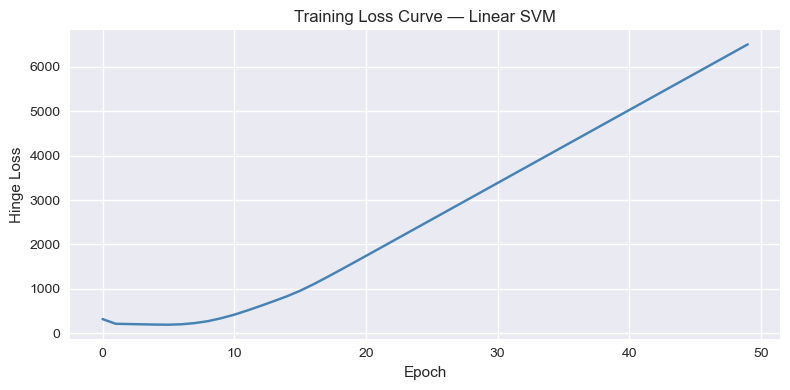

In [4]:
# Loss curve
plt.figure(figsize=(8, 4))
plt.plot(svm_scratch.losses, color='steelblue')
plt.title('Training Loss Curve — Linear SVM')
plt.xlabel('Epoch')
plt.ylabel('Hinge Loss')
plt.tight_layout()
plt.show()

## 3. SVM with Scikit-Learn

In [5]:
# Linear kernel
svm_linear = SVC(kernel='linear', C=1.0, random_state=42)
svm_linear.fit(X_train_scaled, y_train)
y_pred_linear = svm_linear.predict(X_test_scaled)

print("Scikit-Learn SVM (Linear Kernel):")
print(classification_report(y_test, y_pred_linear))

Scikit-Learn SVM (Linear Kernel):
              precision    recall  f1-score   support

           0       0.89      0.97      0.93        87
           1       0.97      0.91      0.94       110

    accuracy                           0.93       197
   macro avg       0.93      0.94      0.93       197
weighted avg       0.94      0.93      0.93       197



In [6]:
# RBF kernel
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_rbf.fit(X_train_scaled, y_train)
y_pred_rbf = svm_rbf.predict(X_test_scaled)

print("Scikit-Learn SVM (RBF Kernel):")
print(classification_report(y_test, y_pred_rbf))

Scikit-Learn SVM (RBF Kernel):
              precision    recall  f1-score   support

           0       0.87      1.00      0.93        87
           1       1.00      0.88      0.94       110

    accuracy                           0.93       197
   macro avg       0.94      0.94      0.93       197
weighted avg       0.94      0.93      0.93       197



## 4. Evaluation & Visualization

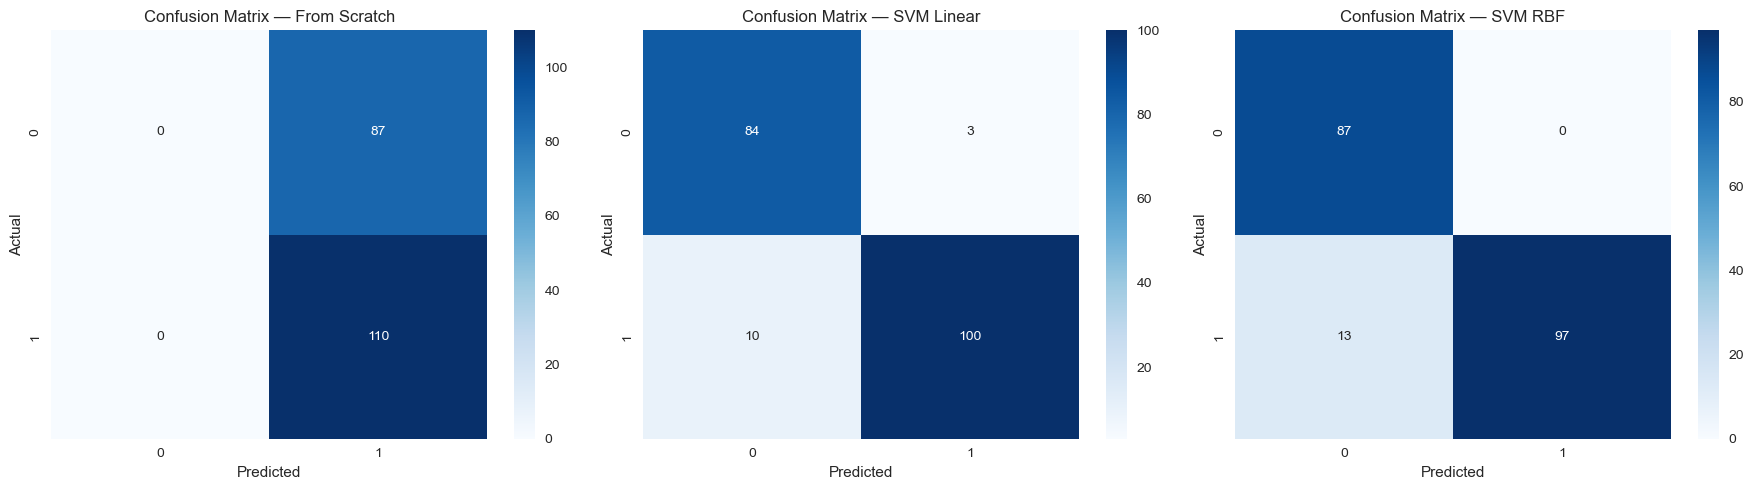

In [7]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, y_pred, title in zip(axes,
                               [y_pred_scratch_binary, y_pred_linear, y_pred_rbf],
                               ['From Scratch', 'SVM Linear', 'SVM RBF']):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'Confusion Matrix — {title}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

## 5. Conclusion

In this notebook, we implemented Support Vector Machines for fraud detection.

Key takeaways:
- SVM finds the maximum-margin hyperplane between classes, making it robust to outliers near the decision boundary.
- Our from-scratch linear SVM uses hinge loss minimization via gradient descent.
- The RBF kernel SVM outperforms the linear kernel by capturing non-linear relationships in the data.
- SVM can be slow to train on large datasets — the balanced subset used here keeps training feasible.
- The $C$ parameter controls the bias-variance trade-off: larger $C$ fits the training data more closely.